# GB84 Model Testing Using in-situ measurements from Cabauw, NL

A notebook to perform test runs with the python implementation of the Georgakakos and Bras model from *"A Hydrologically Useful Station Precipitation Model"* (1984)

This Jupyter Notebook tests a precipitation model using validated data from the CESAR network as inputs, with a 10min resolution.

The input data used in this model consist of a combined dataset derived from the **Cesar Network surface data** and **Cloudnet MWR profiles** corresponding to Cabauw.
#### Required Inputs

- **Surface Inputs** (from ERA5 Single Levels):
  - 2-meter air temperature
  - Surface pressure
  - 2-meter dew point temperature



In [1]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from GB84 import calculations_for_convection, rho_m, v,cloud_heights, h_out, phi, f

# Table of Contents

1. [Loading the data](#Loading-the-data)
2. [Running the model](#Running-the-model)
3. [Visualizing the outputs](#Visualizing-the-outputs)
4. [Result Analysis](#Result-Analysis)


## Loading the Data


After loading the dataset, only the data corresponding to the **desired time interval** are selected for further analysis.


In [2]:
#choose time period of runs
slice_str = "2024-07-16 00:00:00, 2024-07-17 00:00:00"
slice_tuple = tuple(slice_str.split(", "))

#### CESAR surface measurements 

In [3]:
ground_measurements = xr.open_mfdataset(r'..\data\Cabauw_cesar_surface\cesar_surface_meteo_lc1_t10_v1.0_202407.nc')
var = ['TA002','P0','TD002','RH002']
measurements = ground_measurements[var]
measurements = measurements.dropna(dim='time',how='any')
#measurements = measurements.resample(time="1min").interpolate("linear")
measurements_used = measurements.sel(time=slice(*slice_tuple))

In [4]:
time = measurements_used.sel(time=slice(*slice_tuple)).time
dt_seconds = np.diff(time).astype('timedelta64[s]').astype(float)

#### Radiometer LWP 

The liquid water path as measured from the MWR in Cabauw, to be used as the initial state

In [5]:
radiometer = xr.open_mfdataset(r'..\data\Cabaw_radiometer\*.nc')
radiometer_lwp = radiometer['lwp'].sel(time=time,method='nearest')

C:\Users\chari\AppData\Local\Temp\ipykernel_39272\3086603202.py:1: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  radiometer = xr.open_mfdataset(r'..\data\Cabaw_radiometer\*.nc')


Storing the time values and the timestep.

In [6]:
#inputs

#temperature on the ground
T_surf = measurements_used['TA002'].values #[K]


#pressure
p_surf = measurements_used['P0'].values*100  #[Pa]

#dew point temperature
T_d_arr = measurements_used['TD002'].values     #[K]

#state
X = np.zeros(len(T_surf))
X[0] = 0#radiometer_lwp[0]   #initial state in kg/m2 taken from radiometer LWP

#### Parsivel rainfall data

Reading and storing the Parsivel 1 rainfall measurements from Cabauw, which are to be used for the assessment of the model's performance and/or as inputs to the Kalman filter.

In [7]:
parsivel_1 = xr.open_dataset(r'..\data\Cabaw_parsivel\PAR001_Cabauw_202407.nc')
reference_date = np.datetime64("1970-01-01")

# Convert minutes into datetime
datetime_values = reference_date + parsivel_1.epoch_time.astype("timedelta64[s]")
parsivel_1['time'] = datetime_values

rain_rate = parsivel_1.rainfall_rate_32bit.sel(time=time,method='nearest')

### Testing the model

#### Initializing Model Output Arrays

Empty arrays are created to store the outputs of the model. These arrays are initialized with dimensions `(time)`.


In [8]:
P = np.zeros(len(T_surf))
P_0 = np.zeros(len(T_surf))
f_arr = np.zeros(len(T_surf))
h_arr = np.zeros(len(T_surf))

#### Model running loop

Loop for the thermodynamical calculations at each timestep and then for the calculation of precipitation rates and state propagation in time

In [9]:
#loop for finding the precipitation given the T_0 and p

for i in range(0,len(T_surf)):
    #inputs
    T_0 = T_surf[i]
    p_0 = p_surf[i]
    T_d = T_d_arr[i]

    #thermodynamics and in cloud calculations
    p_s,T_s,p_t, T_m, T_t,T_s_up, p_s_up = calculations_for_convection(T_0, T_d, p_0, obs=False).run()
    Z_c,Z_b = cloud_heights(T_s,T_t,T_0,p_s,p_t,p_0)

    #fluxes
    rho = rho_m(T_s,T_t,p_s,p_t)
    v_updr = v(T_m,T_s_up)
    O_b,O_t,h_v = h_out(v_updr,Z_c).run()   #outflows and sources of water

    #precipitation
    P[i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()*X[i]

    #state update
    if i<(len(T_surf)-1):
        X[i+1] = X[i] + dt_seconds[i]*(f(T_d,p_0,p_t,T_t,rho,v_updr) - h_out(v_updr,Z_c).run()[2]*X[i])


C:\Users\chari\AppData\Local\Temp\ipykernel_39272\3320343293.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  P[i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()*X[i]


### Plots and results

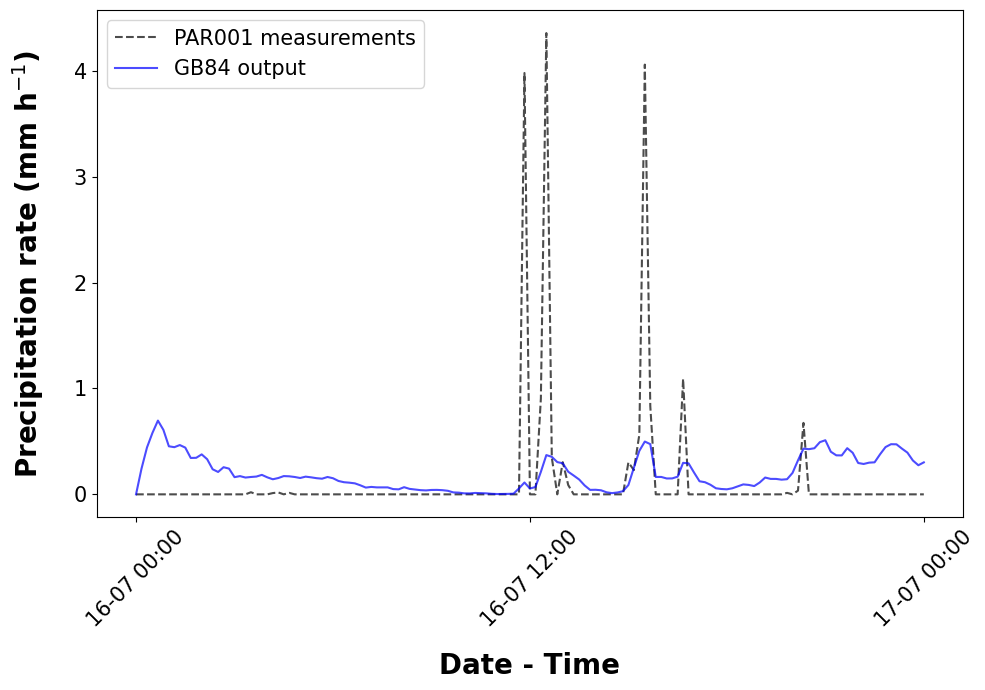

In [10]:
import matplotlib.dates as mdates

plt.figure(figsize=(10, 7))

# Plot lines
plt.plot(time, rain_rate, label='PAR001 measurements', color='black', alpha=0.7, linestyle='--') 
plt.plot(time, P*3600, label='GB84 output', color='blue', alpha=0.7)  # Convert to mm/hr

# Tick label font size (local control)
plt.tick_params(axis='both', labelsize=15)

# Time axis formatting
if hasattr(time, 'dtype') and 'datetime' in str(time.dtype):
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m %H:%M'))
    plt.gca().xaxis.set_major_locator(mdates.HourLocator(byhour=[0,12]))
    plt.setp(plt.gca().xaxis.get_majorticklabels(), rotation=45)
    plt.xlabel('Date - Time', fontweight='bold', fontsize=20, labelpad=15)
else:
    plt.xlabel('Time (min)', fontweight='bold', fontsize=20, labelpad=15)
    plt.gca().xaxis.set_major_locator(MultipleLocator(360))
    plt.xlim(left=0)

# Y-axis label with spacing
plt.ylabel('Precipitation rate (mm h$^{-1}$)', fontweight='bold', fontsize=20, labelpad=20)

# Legend
plt.legend(fontsize=15)

# Optional: clean layout
plt.tight_layout()

plt.show()